In [1]:
import pandas as pd

file_path = '/content/sample_data/MetroPT3(AirCompressor).csv'
df = pd.read_csv(file_path)
df = df.drop(columns=["Unnamed: 0"])


print(f"Successfully read '{file_path}'. First 5 rows:")


Successfully read '/content/sample_data/MetroPT3(AirCompressor).csv'. First 5 rows:
             timestamp    TP2    TP3     H1  DV_pressure  Reservoirs  \
0  2020-02-01 00:00:00 -0.012  9.358  9.340       -0.024       9.358   
1  2020-02-01 00:00:10 -0.014  9.348  9.332       -0.022       9.348   
2  2020-02-01 00:00:19 -0.012  9.338  9.322       -0.022       9.338   
3  2020-02-01 00:00:29 -0.012  9.328  9.312       -0.022       9.328   
4  2020-02-01 00:00:39 -0.012  9.318  9.302       -0.022       9.318   

   Oil_temperature  Motor_current  COMP  DV_eletric  Towers  MPG  LPS  \
0           53.600         0.0400   1.0         0.0     1.0  1.0  0.0   
1           53.675         0.0400   1.0         0.0     1.0  1.0  0.0   
2           53.600         0.0425   1.0         0.0     1.0  1.0  0.0   
3           53.425         0.0400   1.0         0.0     1.0  1.0  0.0   
4           53.475         0.0400   1.0         0.0     1.0  1.0  0.0   

   Pressure_switch  Oil_level  Caudal_impuls

In [2]:
import pandas as pd
pd.options.display.max_columns = None
display(df.describe())

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
count,29147.000000,29147.000000,29147.000000,29146.000000,29146.000000,29146.000000,29146.000000,29146.000000,29146.000000,29146.000000,29146.000000,29146.0,29146.000000,29146.0,29146.0
mean,0.515526,8.955299,8.413083,-0.018300,8.957535,55.528576,1.234591,0.941673,0.058327,0.970802,0.941673,0.0,0.999554,1.0,1.0
std,2.157553,0.561388,2.161896,0.062354,0.560728,3.115023,1.965005,0.234365,0.234365,0.168364,0.234365,0.0,0.021115,0.0,0.0
min,-0.030000,7.588000,-0.030000,-0.026000,7.596000,31.975000,0.030000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.0,1.0
25%,-0.014000,8.466000,8.372000,-0.022000,8.468000,53.800000,0.037500,1.000000,0.000000,1.000000,1.000000,0.0,1.000000,1.0,1.0
50%,-0.012000,8.918000,8.836000,-0.020000,8.922000,56.000000,0.037500,1.000000,0.000000,1.000000,1.000000,0.0,1.000000,1.0,1.0
75%,-0.010000,9.426000,9.366000,-0.018000,9.428000,57.600000,3.747500,1.000000,0.000000,1.000000,1.000000,0.0,1.000000,1.0,1.0
max,10.532000,10.156000,10.152000,5.288000,10.158000,64.175000,7.357500,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.0,1.0


#Visualización de los sensores análogos (variables continuas)

Para cada varibale del dataset se ralizaron gráficas tipo series temporales de 4 horas, para visualizar el comportamiento normal de cada sensor. Tener en cuenta que en el dataset original las mediciones se toman aproximadamente cada 10 segundos.



In [3]:
# Importar librerias
import matplotlib.pyplot as plt
import seaborn as sns

##TP2 : Presión en el compresor


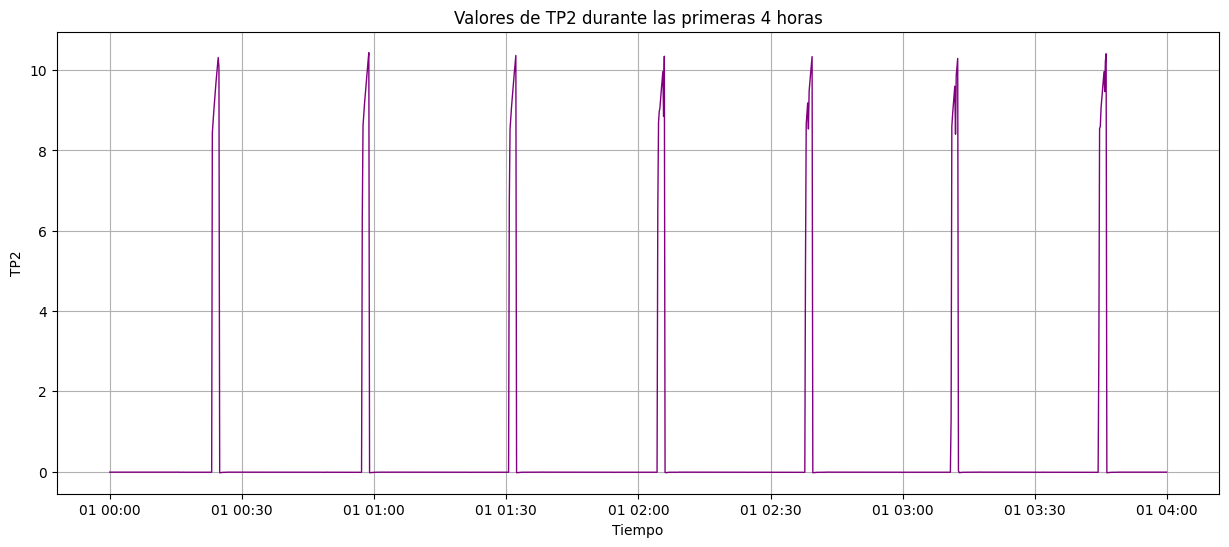

In [4]:
# Ensure 'timestamp' is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 3 hours
end_time = start_time + pd.Timedelta(hours=4)

# Filter the DataFrame for the first 3 hours
df_3hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='TP2', data=df_3hours, color='purple', linewidth=1)

plt.title('Valores de TP2 durante las primeras 4 horas')
plt.xlabel('Tiempo')
plt.ylabel('TP2')
plt.grid(True)
plt.show()

Esta gráfica muestra el funcionamiento normal del sistema, que se activa y se desactiva en periodos de aproximadamente 30 minutos, es el ciclo de funcionamiento del compresor de aire (APU).

*   el periodo de 30 minutos (apróximadamente) antes del pico en la presión corresponde a la fase del ciclo en la que el compresor no está trabajando bajo carga o está apagado, ya que el sistema cuenta con suficiente aire almacenado en los depósitos

*   Cuando la presión del sistema cae por debajo de un umbral (como el mencionado de 8.2 bar para el sensor MPG), el compresor se activa "bajo carga" para reponer el aire, elevando la presión en el compresor (TP2) hasta alcanzar nuevamente su nivel de operación de aproximadamente 10.2 bar



##TP3: Presión en el neumático

Para las variables H1 y TP3, la justificación del comportamiento cíclico es esencialmente la misma, ya que ambas forman parte del sistema de la Unidad de Producción de Aire (APU) y dependen de los mismos ciclos de trabajo del compresor



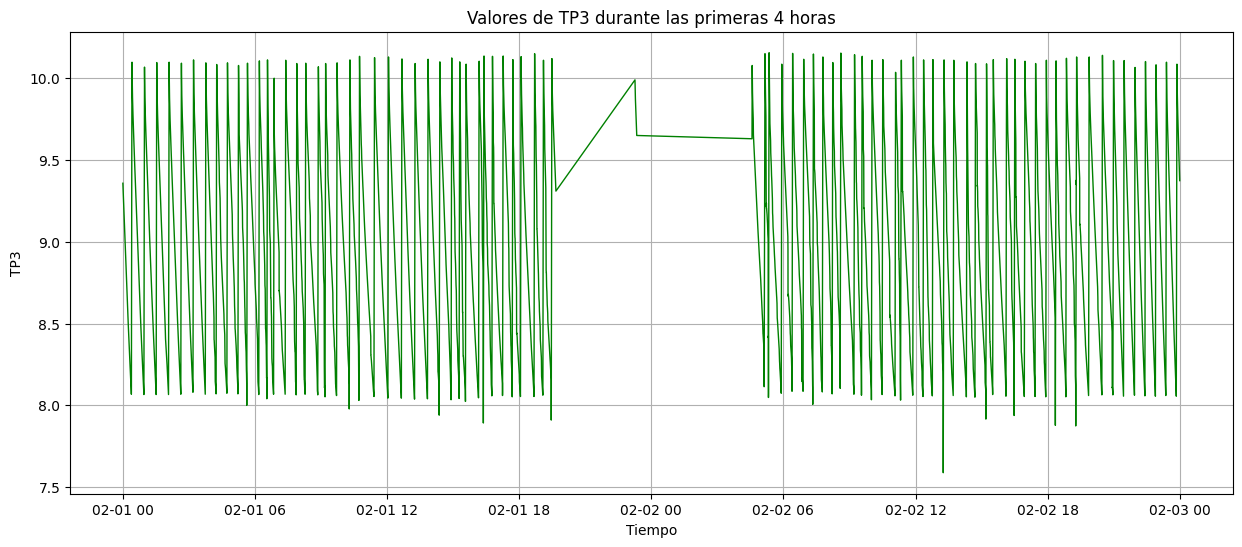

In [17]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 3 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 3 hours
df_3hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='TP3', data=df_3hours, color='green', linewidth=1)

plt.title('Valores de TP3 durante las primeras 4 horas')
plt.xlabel('Tiempo')
plt.ylabel('TP3')
plt.grid(True)
plt.show()

Al igual que TP2, esta variable mide la presión en una parte específica del sistema (el panel neumático). Su valor oscila porque responde a la demanda de aire y a la activación del compresor para reponer la presión cuando esta baja de los niveles operativos

##H1: Válvula de presión


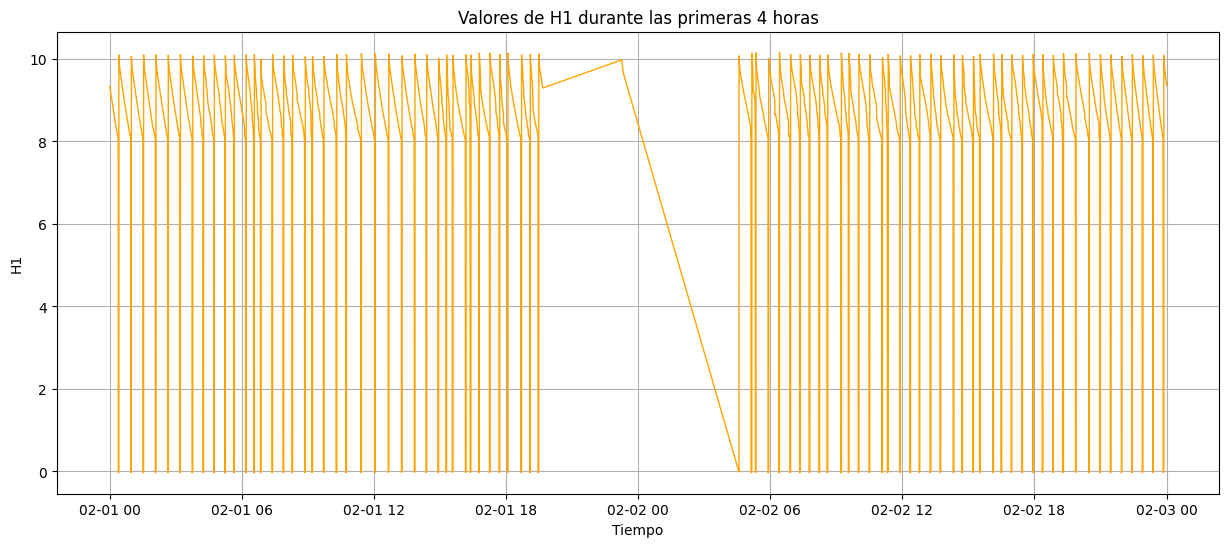

In [16]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 4 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_4hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='H1', data=df_4hours, color='orange', linewidth=1)

plt.title('Valores de H1 durante las primeras 4 horas')
plt.xlabel('Tiempo')
plt.ylabel('H1')
plt.grid(True)
plt.show()

Esta variable representa una válvula que se activa específicamente cuando la presión detectada supera los 10.2 bar. Debido a que el sistema busca alcanzar esa presión de operación durante el ciclo de carga del compresor, el estado de H1 cambia al ritmo de dichos ciclos

##DV_Pressure: presión ejercida por la caída de presión

Esta presión se genera cuando las torres de secado de aire descargan el agua acumulada

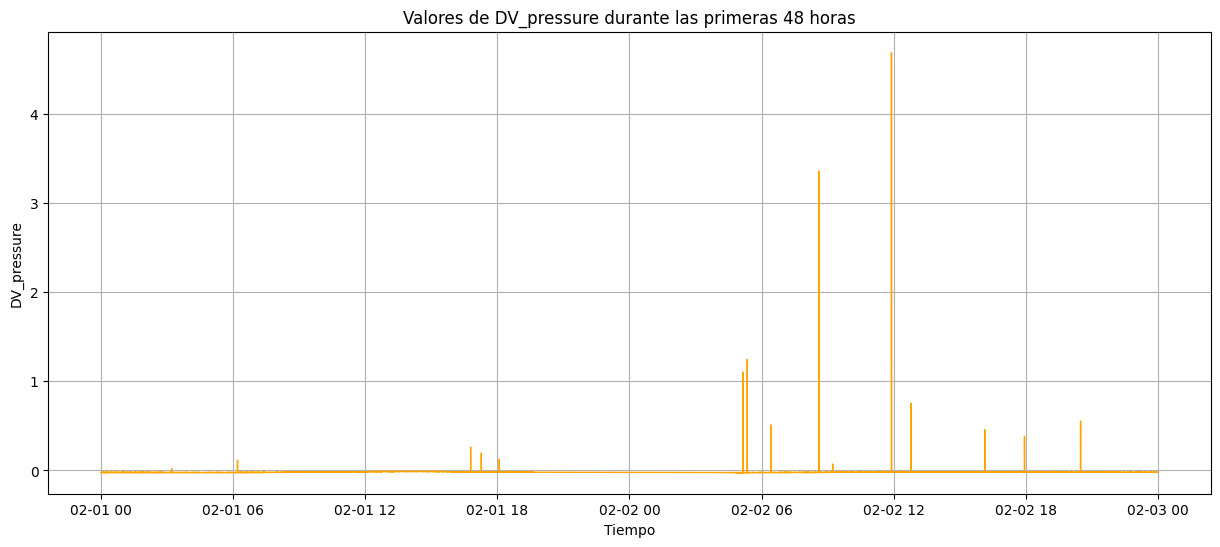

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='DV_pressure', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de DV_pressure durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('DV_pressure')
plt.grid(True)
plt.show()

Aunque a primera vista se pueda pensar que esta variable se comporta de manera aleatoria, los picos en presión dependen de la demanda de aire: El compresor no se activa por tiempo, sino por presión. El sensor MPG activa el compresor cuando la presión en la APU cae por debajo de 8.2 bar. Si el tren está lleno de pasajeros o abre las puertas con mucha frecuencia, consumirá aire más rápido y el ciclo será más corto. Si el tren está estacionado o con pocos pasajeros, el aire durará más y los picos tardarán más en aparecer

##Reservoirs:  Presión dentro de los tanques de aire

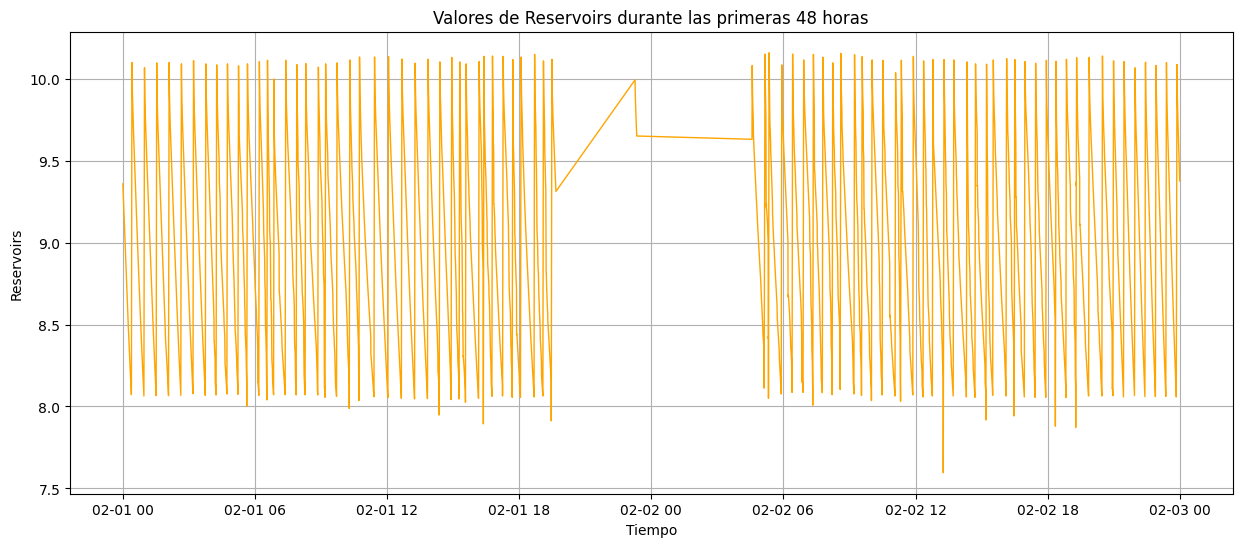

In [13]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='Reservoirs', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de Reservoirs durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('Reservoirs')
plt.grid(True)
plt.show()

La variable DV_pressure mide la presión dentro de los tanques de almacenamiento, actúa como indicador de carga al marcar cero durante la actividad del compresor, registrando picos al purgar humedad. Este proceso se repite en ventanas de aproximadamente 30 minutos, intervalo necesario para observar un ciclo completo de carga y descarga

 En la gráfica podemos observar un ciclos ininterrumpido, esto sirve como alerta temprana de fugas de aire o fallos, las caídas bruscas también se pueden presentar

##Oil Temperature: Temperatura del aceite presente en el compresor

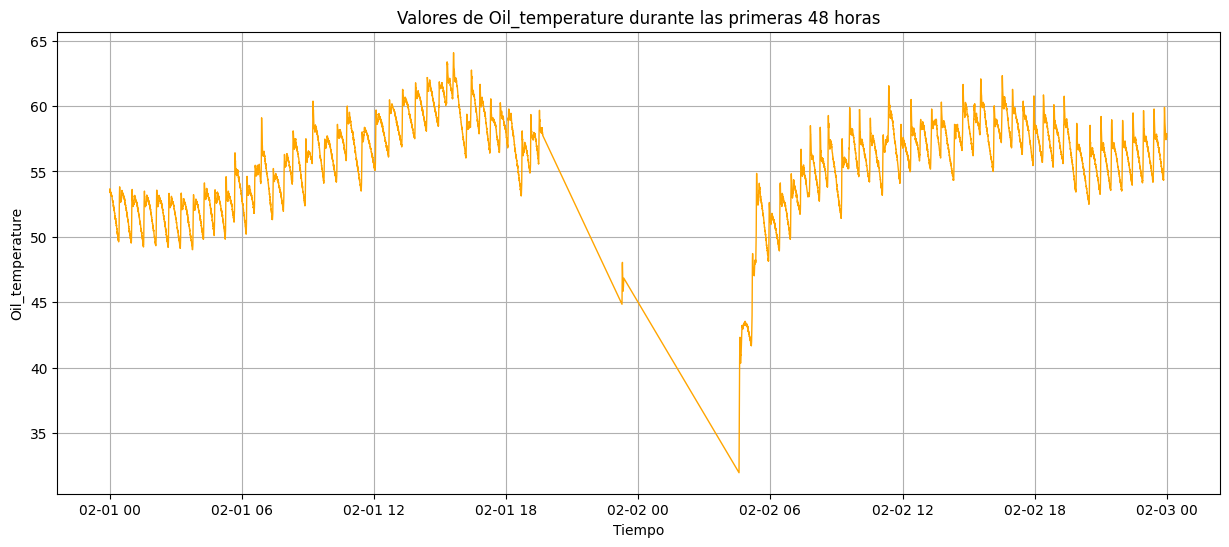

In [15]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='Oil_temperature', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de Oil_temperature durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('Oil_temperature')
plt.grid(True)
plt.show()

En esta variable también se observan picos cada 30 minutos (aproximadamente), esto puede significar una coordinación en los sistemas internos del compresor. La temperatura del aceite está intrínsecamente ligada al funcionamiento del compresor. Cuando el compresor se activa "bajo carga" para llenar los depósitos de aire, la fricción y el trabajo mecánico elevan la temperatura del aceite; cuando el compresor se apaga o trabaja en vacío, la temperatura tiende a estabilizarse o descender

##Motor_current: corriente eléctrica consumida por el motor

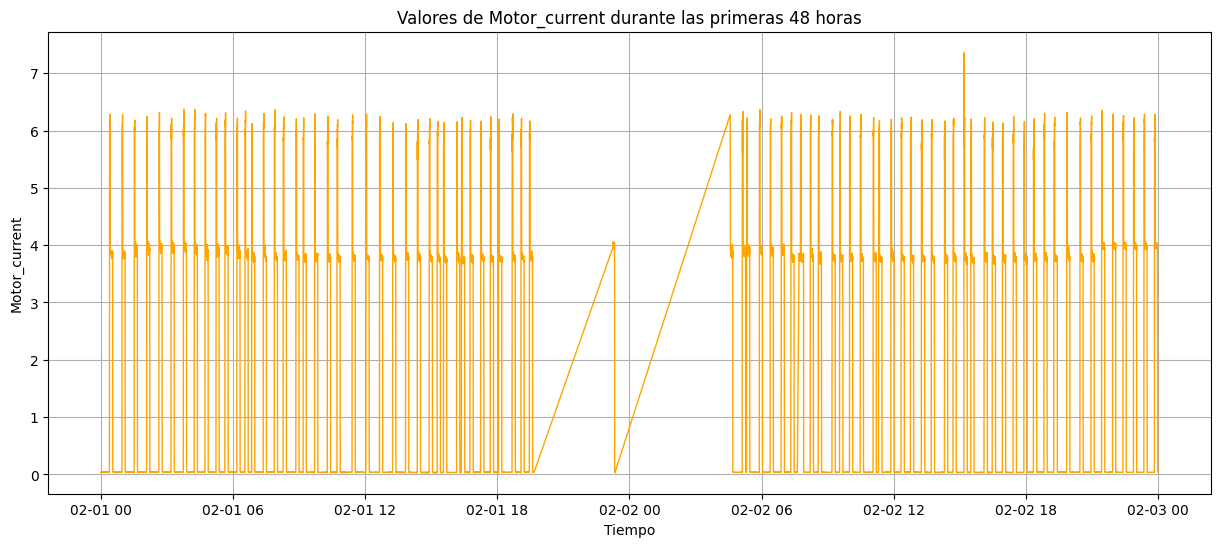

In [18]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='Motor_current', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de Motor_current durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('Motor_current')
plt.grid(True)
plt.show()

Esta variable también tiene la misma periodicidad de 30 minutos, y se mide en Amperios(A)

 El valor de esta variable oscila entre tres estados principales que indican el modo de operación del compresor:



*   Cercano a 0 A: El compresor está completamente apagado.
*   Cercano a 4 A: El compresor está funcionando "en vacío" (offloaded), es decir, el motor gira pero no está produciendo aire para el sistema.
* Cercano a 7 A: El compresor está operando "bajo carga" (under load)trabajando activamente para llenar los depósitos de aire.
  

la variable oscila porque el sistema neumático del tren necesita mantener una presión constante para funciones como el frenado y la suspensión; cuando el aire se consume, el motor se activa (7 A), y cuando los tanques están llenos, descansa (0-4 A)

#Conclusiones de la visualización (Sensores analógicos)

* Comportamiento Cíclico: En condiciones normales, los sensores no son aleatorios, sino que siguen un patrón cíclico de aproximadamente 30 minutos que refleja los periodos de carga y descarga del compresor.

* Sincronización de Presiones: Variables como TP2, TP3 y Reservoirs deben oscilar de forma coordinada; una ruptura en esta sincronía o caídas bruscas
de presión son indicadores claros de fugas de aire.

* Estado del Motor: La variable Motor_current permite confirmar visualmente si el compresor está apagado (0A), trabajando en vacío (4A) o bajo carga (7A), lo que ayuda a validar si el consumo de energía corresponde a la producción de aire esperada.

* Identificación de Anomalías: Las fallas se manifiestan visualmente como picos atípicos, patrones irregulares (en la temperatura del aceite) o caídas catastróficas de presión que obligan al compresor a trabajar sin descanso

#Visualización de los sensores digitales (variables binarias)


Las variables discretas se caracterizan por asumir únicamente dos valores: 0 cuando están inactivas y 1 cuando un evento específico las activa. Están asociadas a cambios de estado operativos o alarmas del sistema

##COMP: Señal eléctrica de la válvula de admisión

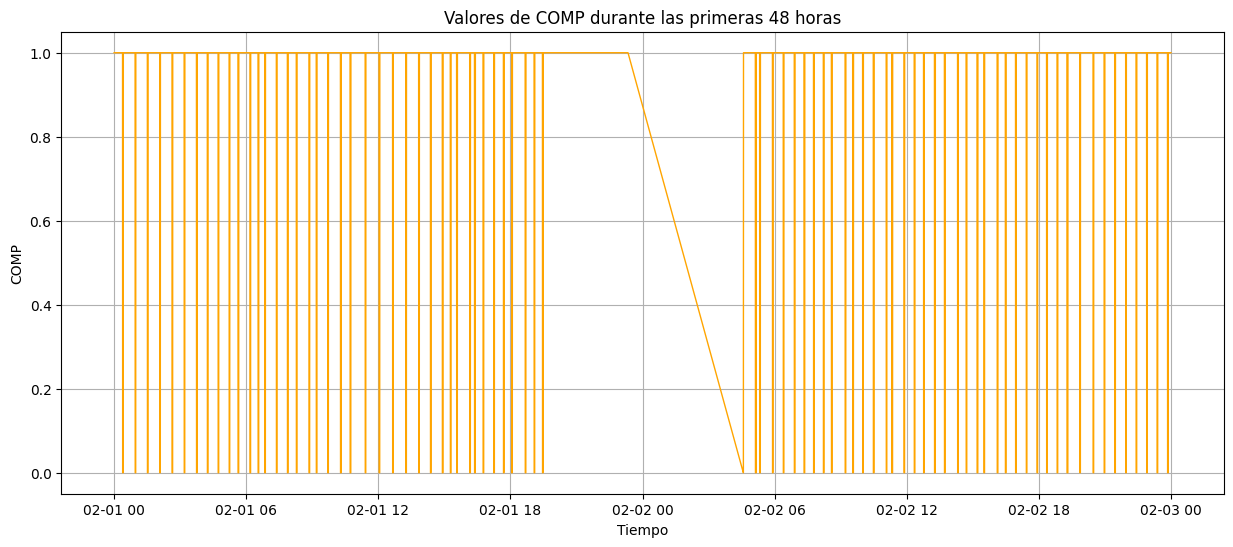

In [19]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='COMP', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de COMP durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('COMP')
plt.grid(True)
plt.show()

Esta variable se activa (1) cuando no hay admisión de aire en el compresor, lo que significa que el equipo está apagado o funcionando en vacío (offloaded). Pasa a 0 cuando el compresor trabaja bajo carga. Su comportamiento está dictado por la demanda de aire y es influenciado directamente por el sensor MPG.

##DV_eletric: Señal de la válvula de salida

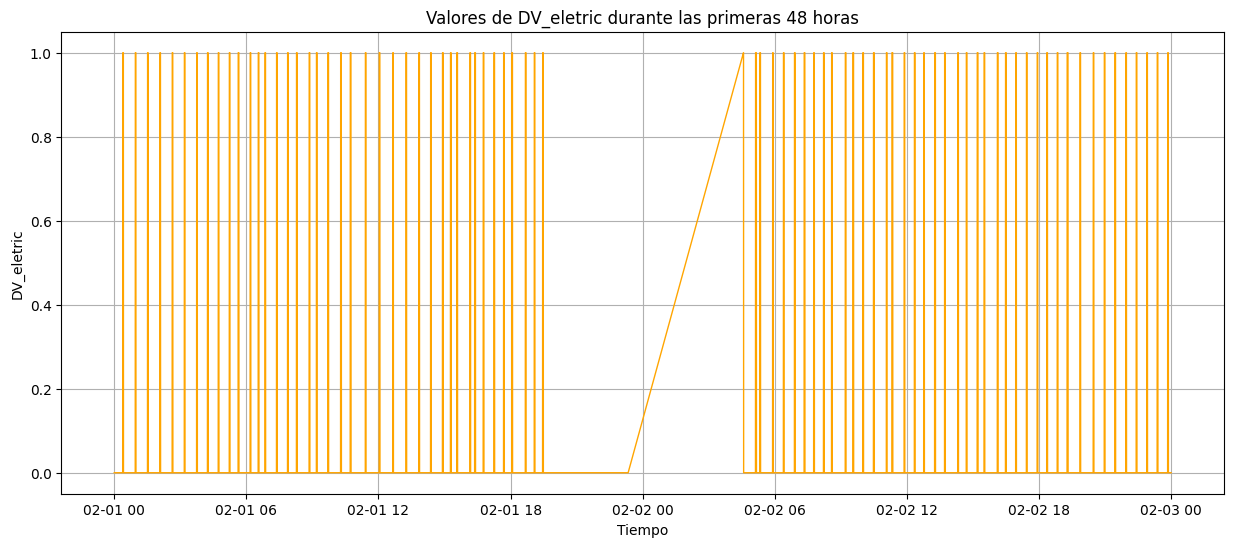

In [20]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='DV_eletric', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de DV_eletric durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('DV_eletric')
plt.grid(True)
plt.show()

Funciona de forma complementaria a la lógica de carga; cuando está activa (1), el compresor está trabajando bajo carga. Si está inactiva (0), el compresor está apagado o en vacío.

##Towers: torres de secado

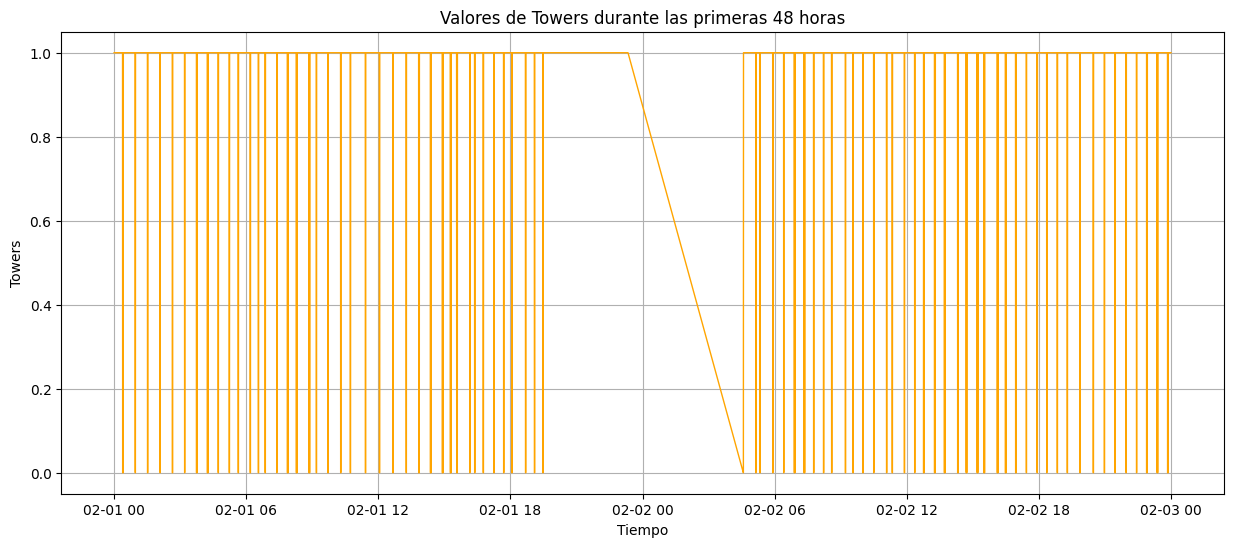

In [21]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='Towers', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de Towers durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('Towers')
plt.grid(True)
plt.show()

Esta variable define qué torre está operando. Cuando es 0, la torre uno está trabajando; cuando es 1, es la torre dos la que seca el aire o drena la humedad. Su variación permite el intercambio cíclico entre las torres para un secado eficiente.

##MPG: Gobernador de presión

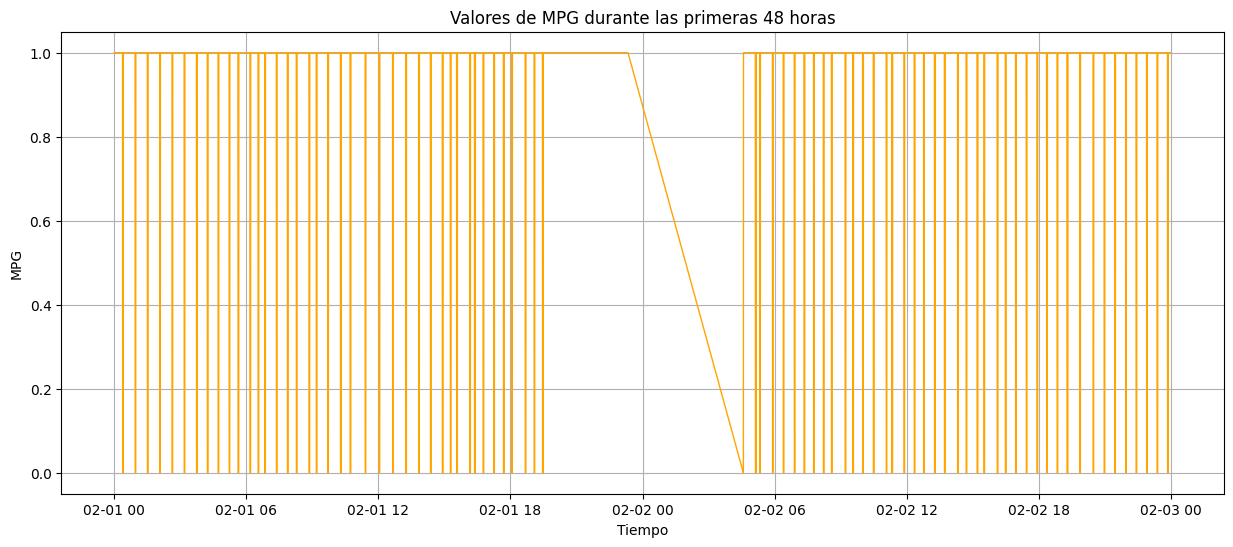

In [22]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='MPG', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de MPG durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('MPG')
plt.grid(True)
plt.show()

 Es el responsable de iniciar los ciclos de carga. Cambia a 1 para activar la válvula de admisión cuando la presión en la APU cae por debajo de los 8.2 bar. Su activación provoca que la variable COMP asuma el mismo comportamiento

##LPS: Señal de baa presión

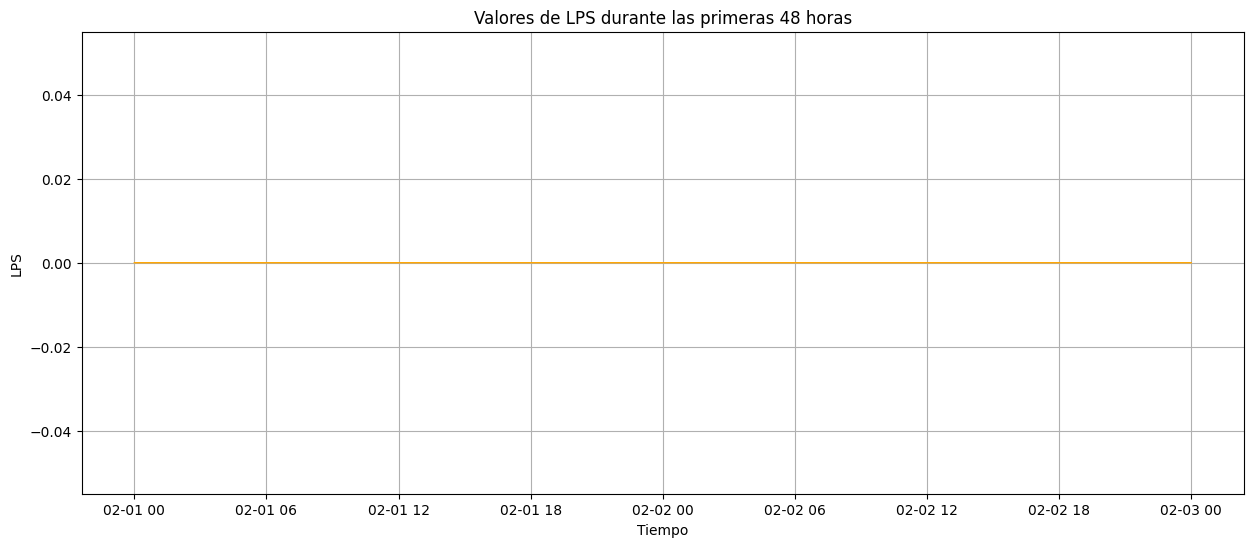

In [23]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='LPS', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de LPS durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('LPS')
plt.grid(True)
plt.show()

##Oil_level: Nivel de aceite

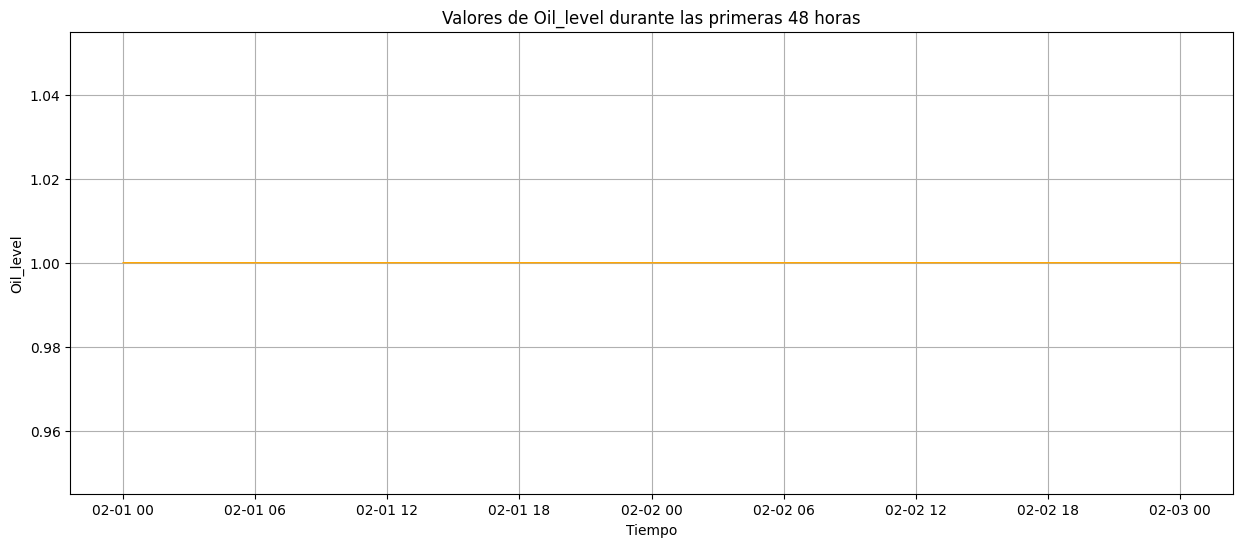

In [26]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='Oil_level', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de Oil_level durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('Oil_level')
plt.grid(True)
plt.show()

Es un sensor de estado crítico que se activa (1) si el nivel de aceite del compresor está por debajo de los valores esperados. En operación normal, su valor es 0.

##Pressure_switch: interrumptor de presión

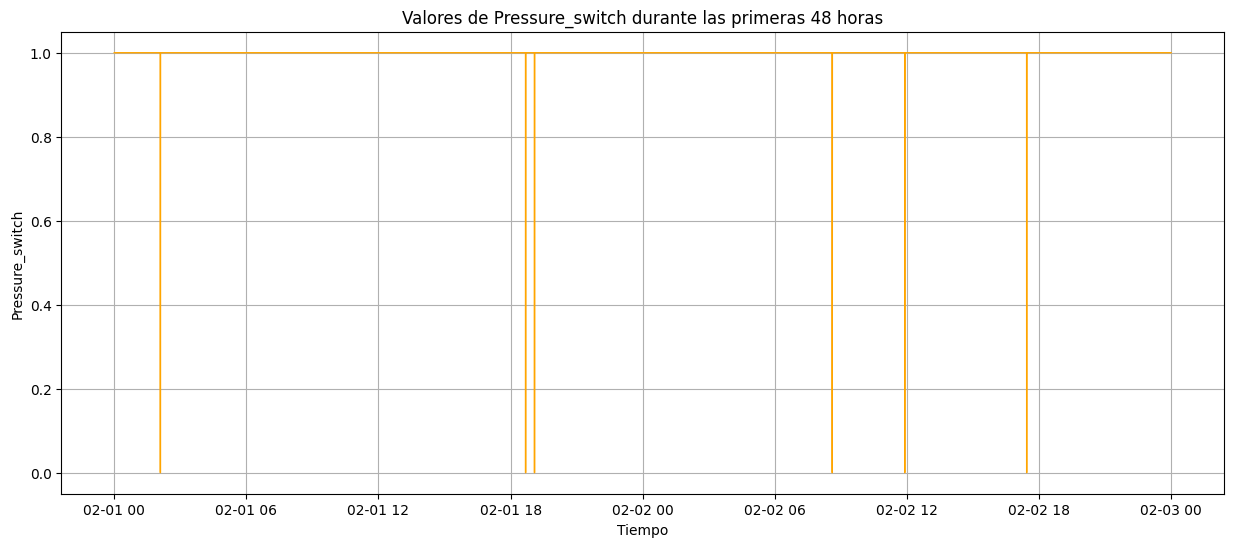

In [24]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='Pressure_switch', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de Pressure_switch durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('Pressure_switch')
plt.grid(True)
plt.show()

Se activa (1) cuando se detecta presión en la válvula de control piloto. Su variación depende de la presencia de flujo de control en esa etapa del sistema neumático.

##Caudal_impulses

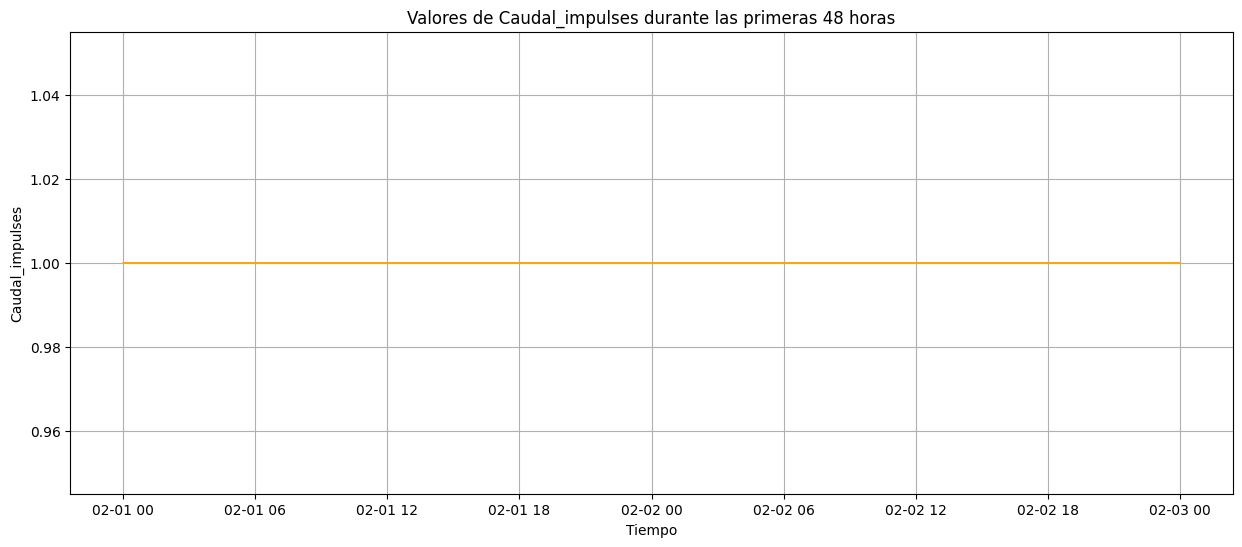

In [27]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Get the start time of the dataset
start_time = df['timestamp'].min()

# Calculate the end time for 48 hours
end_time = start_time + pd.Timedelta(hours=48)

# Filter the DataFrame for the first 4 hours
df_48hours = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='Caudal_impulses', data=df_48hours, color='orange', linewidth=1)

plt.title('Valores de Caudal_impulses durante las primeras 48 horas')
plt.xlabel('Tiempo')
plt.ylabel('Caudal_impulses')
plt.grid(True)
plt.show()

Es una señal producida por el caudalímetro que genera pulsos para indicar la existencia de flujo de aire por segundo. Sus variaciones (0 a 1) son muy rápidas y frecuentes siempre que hay aire circulando por el panel de control.Que se mantenga en 1 representa que siempre hay flujo de aire, aunque no es una medida muy confiable, ya que las fugas también provocan un flujo de aire constante, pero en forma de fuga